In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
import pylab as plt
import pandas as pd
import numpy as np
from loguru import logger
import seaborn as sns

from stable_baselines3 import PPO, DQN

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler, \
    MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Noise import UniformSpikeNoise
from vimms.Evaluation import evaluate_real
from vimms.Chemicals import ChemicalMixtureFromMZML
from vimms.Roi import RoiBuilderParams, SmartRoiParams

from mass_spec_utils.data_import.mzmine import load_picked_boxes

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import evaluate, run_method
from vimms_gym.common import METHOD_RANDOM, METHOD_FULLSCAN, METHOD_TOPN, METHOD_PPO, METHOD_DQN

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


# 1. Parameters

In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (2000, 5000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E4, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 120
exclusion_t_0 = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mz_sampler = UniformMZFormulaSampler(min_mz=min_mz, max_mz=max_mz)
ri_sampler = UniformRTAndIntensitySampler(min_rt=min_rt, max_rt=max_rt,
                                          min_log_intensity=min_log_intensity,
                                          max_log_intensity=max_log_intensity)
cr_sampler = GaussianChromatogramSampler()
samplers = {
    'mz': mz_sampler,
    'rt_intensity': ri_sampler,
    'chromatogram': cr_sampler
}

In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [11]:
max_peaks = 200
in_dir = 'results'

In [12]:
n_eval_episodes = 10
deterministic = True

# 2. Evaluation

#### Generate some chemical sets

In [13]:
set_log_level_warning()

1

In [14]:
eval_dir = 'evaluation'
methods = [
    METHOD_PPO,
    METHOD_TOPN,
    METHOD_RANDOM,
]

In [15]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0
1
2
3
4
5
6
7
8
9


#### Run different methods

In [16]:
for chems in chem_list:
    print(len(chems))

4392
4546
3842
4920
4576
4174
3695
3889
3771
4550


In [17]:
max_peaks

200

In [18]:
out_dir = eval_dir
in_dir, out_dir

('results', 'evaluation')

#### Compare to Top-10

In [19]:
env_name = 'DDAEnv'
model_name = 'PPO'
intensity_threshold = 0.5

In [20]:
method_eval_results = {}
for method in methods:

    effective_rt_tol = rt_tol
    copy_params = dict(params)        
    copy_params['env']['rt_tol'] = effective_rt_tol
    
    banner = 'method = %s max_peaks = %d rt_tol = %d' % (method, max_peaks, effective_rt_tol)
    print(banner)
    print()

    if method == METHOD_PPO:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
        model = PPO.load(fname)
    elif method == METHOD_DQN:
        fname = os.path.join(in_dir, '%s_%s.zip' % (env_name, model_name))
        model = DQN.load(fname)
    else:
        model = None

    episodic_results = run_method(env_name, copy_params, max_peaks, chem_list, method, out_dir, 
                                  N=N, min_ms1_intensity=min_ms1_intensity, model=model,
                                  print_eval=True, print_reward=False, intensity_threshold=intensity_threshold)
    eval_results = [er.eval_res for er in episodic_results]
    method_eval_results[method] = eval_results
    print()

method = PPO max_peaks = 200 rt_tol = 120

{'coverage_prop': '0.774', 'intensity_prop': '0.389', 'ms1/ms2 ratio': '0.064', 'efficiency': '0.960', 'TP': '1208', 'FP': '1555', 'FN': '1629', 'precision': '0.437', 'recall': '0.426', 'f1': '0.431'}
{'coverage_prop': '0.749', 'intensity_prop': '0.371', 'ms1/ms2 ratio': '0.063', 'efficiency': '0.958', 'TP': '1132', 'FP': '1621', 'FN': '1793', 'precision': '0.411', 'recall': '0.387', 'f1': '0.399'}
{'coverage_prop': '0.841', 'intensity_prop': '0.401', 'ms1/ms2 ratio': '0.067', 'efficiency': '0.915', 'TP': '1063', 'FP': '1633', 'FN': '1146', 'precision': '0.394', 'recall': '0.481', 'f1': '0.433'}
{'coverage_prop': '0.717', 'intensity_prop': '0.364', 'ms1/ms2 ratio': '0.063', 'efficiency': '0.993', 'TP': '1205', 'FP': '1534', 'FN': '2181', 'precision': '0.440', 'recall': '0.356', 'f1': '0.393'}
{'coverage_prop': '0.758', 'intensity_prop': '0.381', 'ms1/ms2 ratio': '0.063', 'efficiency': '0.976', 'TP': '1188', 'FP': '1567', 'FN': '1821', 'precisi

#### Test classic controllers in ViMMS

In [21]:
from vimms.MassSpec import IndependentMassSpectrometer
from vimms.Controller import TopNController, TopN_SmartRoiController, WeightedDEWController
from vimms.Environment import Environment

Run Top-N Controller

In [22]:
method = 'TopN_Controller'
print('method = %s' % method)
print()

effective_rt_tol = rt_tol
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    controller = TopNController(ionisation_mode, N, isolation_window, mz_tol, effective_rt_tol,
                                min_ms1_intensity)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = TopN_Controller

Episode 0 finished
{'coverage_prop': '0.823', 'intensity_prop': '0.251', 'ms1/ms2 ratio': '0.102', 'efficiency': '1.088', 'TP': '590', 'FP': '2350', 'FN': '1452', 'precision': '0.201', 'recall': '0.289', 'f1': '0.237'}
Episode 1 finished
{'coverage_prop': '0.801', 'intensity_prop': '0.246', 'ms1/ms2 ratio': '0.101', 'efficiency': '1.094', 'TP': '586', 'FP': '2336', 'FN': '1624', 'precision': '0.201', 'recall': '0.265', 'f1': '0.228'}
Episode 2 finished
{'coverage_prop': '0.897', 'intensity_prop': '0.251', 'ms1/ms2 ratio': '0.102', 'efficiency': '1.037', 'TP': '524', 'FP': '2366', 'FN': '952', 'precision': '0.181', 'recall': '0.355', 'f1': '0.240'}
Episode 3 finished
{'coverage_prop': '0.756', 'intensity_prop': '0.242', 'ms1/ms2 ratio': '0.101', 'efficiency': '1.117', 'TP': '643', 'FP': '2253', 'FN': '2024', 'precision': '0.222', 'recall': '0.241', 'f1': '0.231'}
Episode 4 finished
{'coverage_prop': '0.797', 'intensity_prop': '0.245', 'ms1/ms2 ratio': '0.101', 

Run SmartROI Controller

In [23]:
method = 'SmartROI_Controller'
print('method = %s' % method)
print()

effective_rt_tol = exclusion_t_0
eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    roi_params = RoiBuilderParams(min_roi_intensity=500, min_roi_length=0)    
    smartroi_params = SmartRoiParams()
    controller = TopN_SmartRoiController(ionisation_mode, isolation_window, N, mz_tol, effective_rt_tol,
                                min_ms1_intensity, roi_params, smartroi_params)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = SmartROI_Controller

Episode 0 finished
{'coverage_prop': '0.814', 'intensity_prop': '0.350', 'ms1/ms2 ratio': '0.106', 'efficiency': '1.084', 'TP': '652', 'FP': '2260', 'FN': '1480', 'precision': '0.224', 'recall': '0.306', 'f1': '0.259'}
Episode 1 finished
{'coverage_prop': '0.791', 'intensity_prop': '0.344', 'ms1/ms2 ratio': '0.105', 'efficiency': '1.088', 'TP': '665', 'FP': '2224', 'FN': '1657', 'precision': '0.230', 'recall': '0.286', 'f1': '0.255'}
Episode 2 finished
{'coverage_prop': '0.890', 'intensity_prop': '0.375', 'ms1/ms2 ratio': '0.106', 'efficiency': '1.035', 'TP': '611', 'FP': '2240', 'FN': '991', 'precision': '0.214', 'recall': '0.381', 'f1': '0.274'}
Episode 3 finished
{'coverage_prop': '0.745', 'intensity_prop': '0.333', 'ms1/ms2 ratio': '0.105', 'efficiency': '1.108', 'TP': '729', 'FP': '2130', 'FN': '2061', 'precision': '0.255', 'recall': '0.261', 'f1': '0.258'}
Episode 4 finished
{'coverage_prop': '0.787', 'intensity_prop': '0.346', 'ms1/ms2 ratio': '0.10

Run WeightedDEW Controller

In [24]:
method = 'WeightedDEW_Controller'
print('method = %s' % method)
print()

eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    controller = WeightedDEWController(ionisation_mode, N, isolation_window, mz_tol, rt_tol,
                                min_ms1_intensity, exclusion_t_0=exclusion_t_0)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i), save_eval=True)
    env.run()
    
    eval_res = evaluate(env, intensity_threshold)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = WeightedDEW_Controller

Episode 0 finished
{'coverage_prop': '0.528', 'intensity_prop': '0.366', 'ms1/ms2 ratio': '0.102', 'efficiency': '0.697', 'TP': '1314', 'FP': '532', 'FN': '2546', 'precision': '0.712', 'recall': '0.340', 'f1': '0.461'}
Episode 1 finished
{'coverage_prop': '0.512', 'intensity_prop': '0.359', 'ms1/ms2 ratio': '0.101', 'efficiency': '0.700', 'TP': '1305', 'FP': '543', 'FN': '2698', 'precision': '0.706', 'recall': '0.326', 'f1': '0.446'}
Episode 2 finished
{'coverage_prop': '0.558', 'intensity_prop': '0.399', 'ms1/ms2 ratio': '0.102', 'efficiency': '0.644', 'TP': '1327', 'FP': '436', 'FN': '2079', 'precision': '0.753', 'recall': '0.390', 'f1': '0.513'}
Episode 3 finished
{'coverage_prop': '0.505', 'intensity_prop': '0.352', 'ms1/ms2 ratio': '0.101', 'efficiency': '0.747', 'TP': '1336', 'FP': '571', 'FN': '3013', 'precision': '0.701', 'recall': '0.307', 'f1': '0.427'}
Episode 4 finished
{'coverage_prop': '0.510', 'intensity_prop': '0.357', 'ms1/ms2 ratio': '

#### Plotting

Flatten data into dataframe

In [25]:
data = []
for method in method_eval_results:
    eval_results = method_eval_results[method]
    for eval_res in eval_results:
        row = (
            method, 
            float(eval_res['coverage_prop']), 
            float(eval_res['intensity_prop']), 
            float(eval_res['ms1/ms2 ratio']), 
            float(eval_res['efficiency']),
            float(eval_res['precision']),
            float(eval_res['recall']),
            float(eval_res['f1']),            
        )
        data.append(row)
        
df = pd.DataFrame(data, columns=['method', 'coverage_prop', 'intensity_prop', 'ms1/ms2_ratio', 'efficiency', 'precision', 'recall', 'f1'])
# df.set_index('method', inplace=True)
df.head()

,method,coverage_prop,intensity_prop,ms1/ms2_ratio,efficiency,precision,recall,f1
0,PPO,0.774,0.389,0.064,0.960,0.437,0.426,0.431
1,PPO,0.749,0.371,0.063,0.958,0.411,0.387,0.399
2,PPO,0.841,0.401,0.067,0.915,0.394,0.481,0.433
3,PPO,0.717,0.364,0.063,0.993,0.440,0.356,0.393
4,PPO,0.758,0.381,0.063,0.976,0.431,0.395,0.412


In [26]:
sns.set_context("poster")

Text(0.5, 1.0, 'Coverage Proportion')

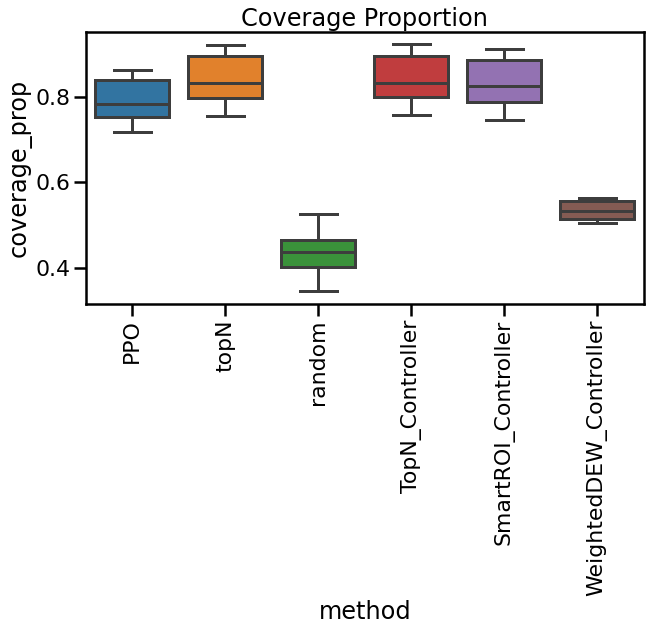

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='coverage_prop')
plt.xticks(rotation=90)
plt.title('Coverage Proportion')

Text(0.5, 1.0, 'Intensity Proportion')

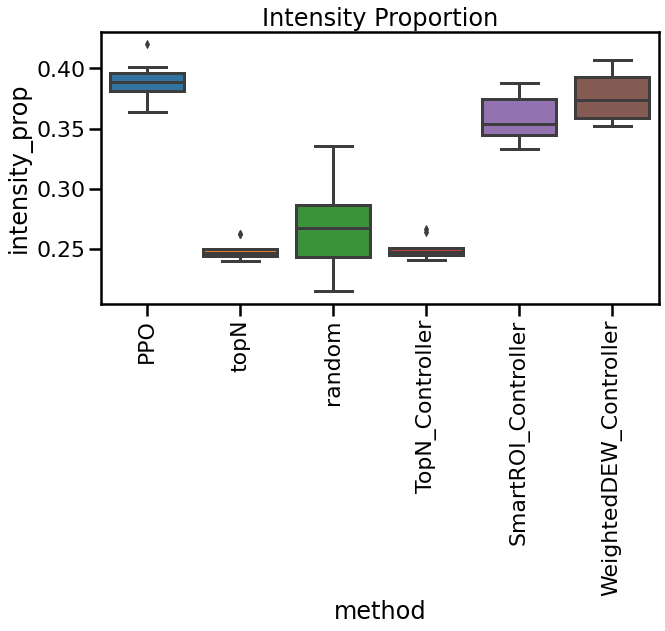

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='intensity_prop')
plt.xticks(rotation=90)
plt.title('Intensity Proportion')

Text(0.5, 1.0, 'MS1/MS2 Ratio')

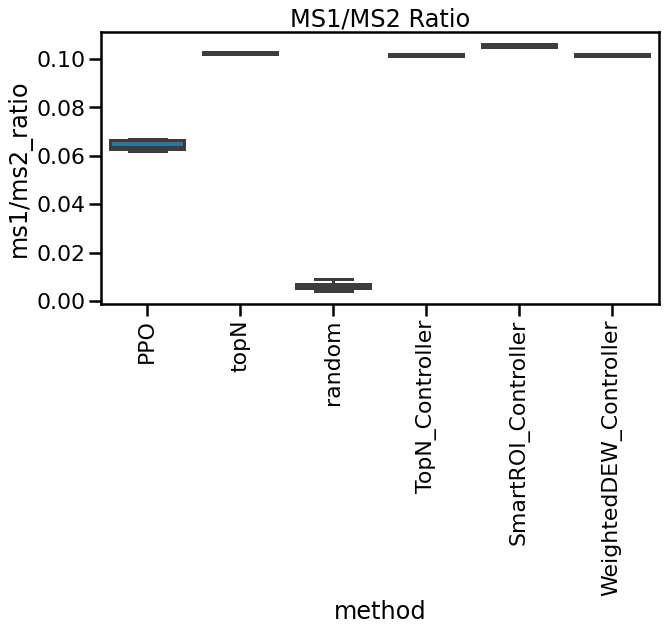

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='ms1/ms2_ratio')
plt.xticks(rotation=90)
plt.title('MS1/MS2 Ratio')

Text(0.5, 1.0, 'Efficiency')

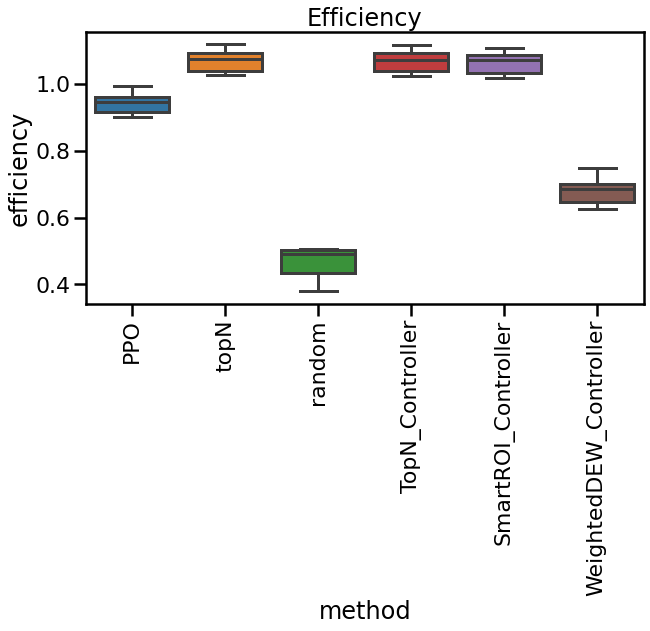

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='efficiency')
plt.xticks(rotation=90)
plt.title('Efficiency')

Text(0.5, 1.0, 'Precision')

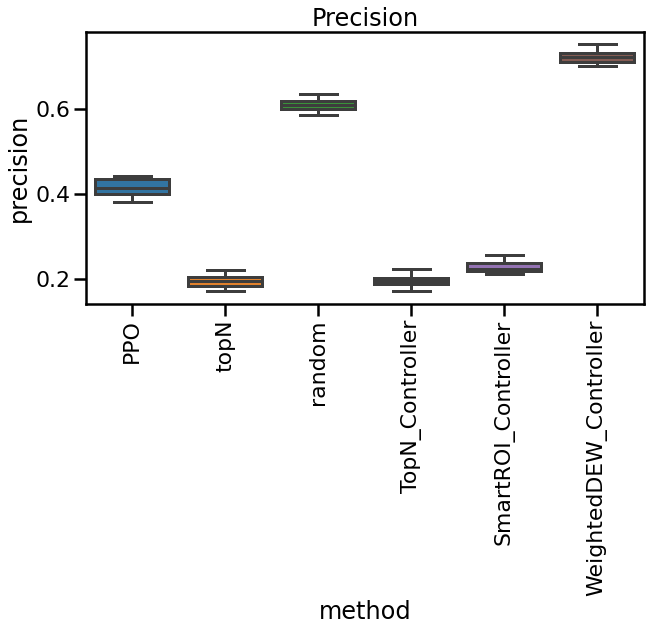

In [31]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='precision')
plt.xticks(rotation=90)
plt.title('Precision')

Text(0.5, 1.0, 'Recall')

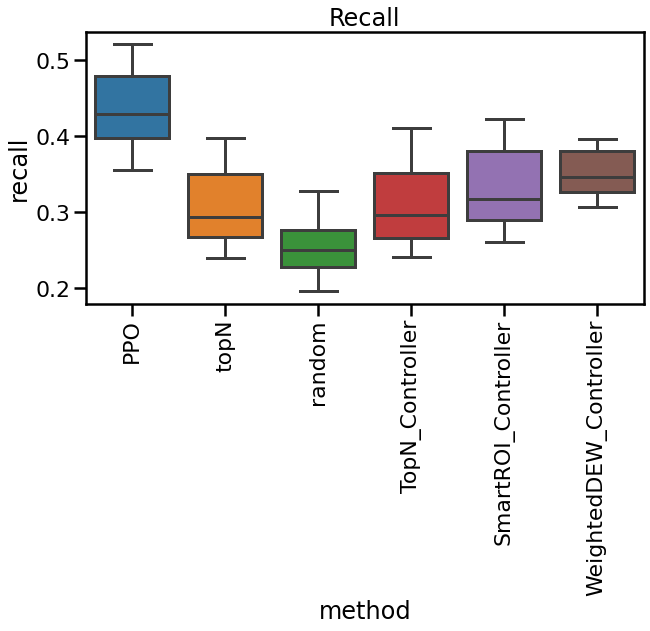

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='recall')
plt.xticks(rotation=90)
plt.title('Recall')

Text(0.5, 1.0, 'F1')

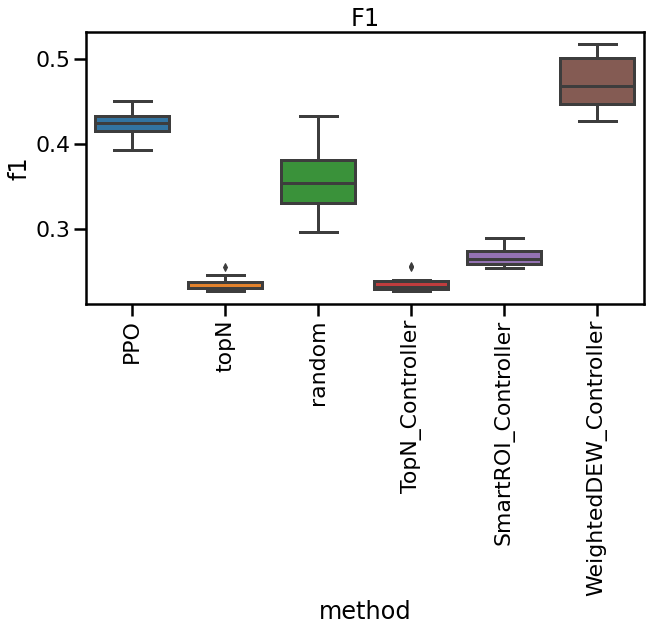

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='f1')
plt.xticks(rotation=90)
plt.title('F1')